In [5]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [6]:
(train_X, train_y), (test_X, test_y) = mnist.load_data()

print("Treniravimo duomenys:", train_X.shape)

Treniravimo duomenys: (60000, 28, 28)


In [15]:
test_X.shape

(10000, 28, 28)

In [7]:
# Paverčiame 28x28 į 784
X = train_X.reshape(train_X.shape[0], -1)

# Standartizacija
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [9]:
explained_variance = pca.explained_variance_ratio_

print("\nPirmų 10 komponentų paaiškinta dispersija:")
for i in range(10):
    print(f"PC{i+1}: {explained_variance[i]*100:.2f}%")


Pirmų 10 komponentų paaiškinta dispersija:
PC1: 5.65%
PC2: 4.08%
PC3: 3.74%
PC4: 2.89%
PC5: 2.52%
PC6: 2.19%
PC7: 1.92%
PC8: 1.75%
PC9: 1.54%
PC10: 1.40%


In [14]:
sum(pca.explained_variance_ratio_[:10])

np.float64(0.2767081828674871)

In [10]:
variance_2d = np.sum(explained_variance[:2])
print(f"\nPirmi du komponentai paaiškina: {variance_2d*100:.2f}% dispersijos")


Pirmi du komponentai paaiškina: 9.72% dispersijos


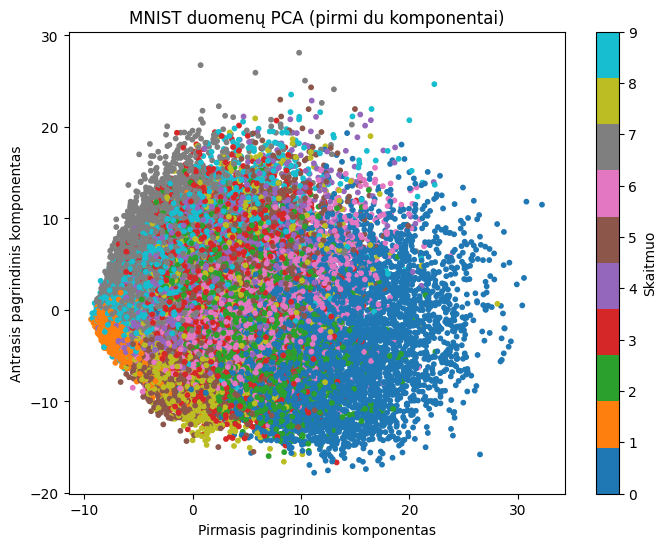

In [11]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    X_pca[:,0], X_pca[:,1],
    c=train_y, cmap='tab10', s=10
)

plt.xlabel("Pirmasis pagrindinis komponentas")
plt.ylabel("Antrasis pagrindinis komponentas")
plt.title("MNIST duomenų PCA (pirmi du komponentai)")
plt.colorbar(scatter, label="Skaitmuo")
plt.show()

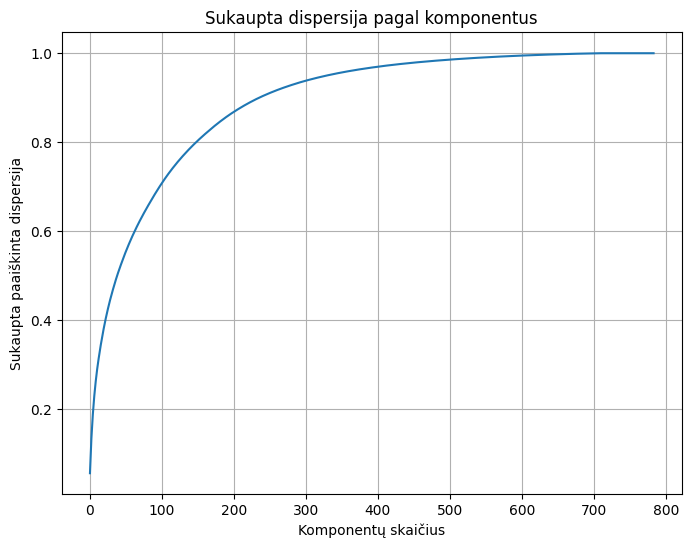

In [12]:
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8,6))
plt.plot(cumulative_variance)

plt.xlabel("Komponentų skaičius")
plt.ylabel("Sukaupta paaiškinta dispersija")
plt.title("Sukaupta dispersija pagal komponentus")
plt.grid()
plt.show()

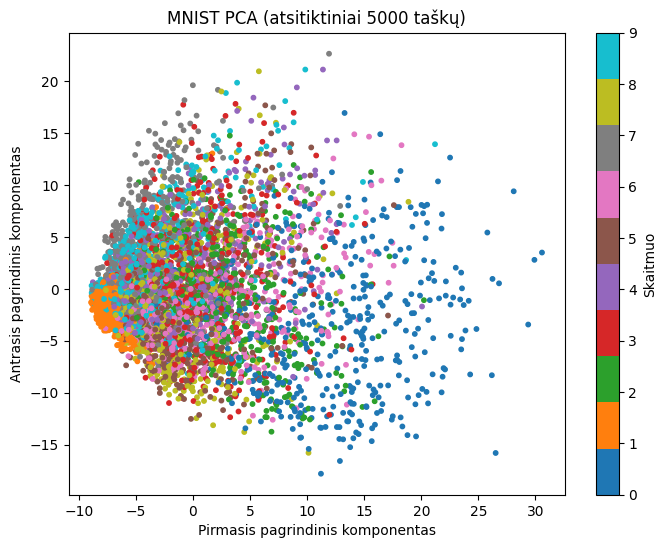

In [13]:
idx = np.random.choice(len(X_pca), 5000, replace=False)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[idx,0], X_pca[idx,1], c=train_y[idx], cmap='tab10', s=10)

plt.xlabel("Pirmasis pagrindinis komponentas")
plt.ylabel("Antrasis pagrindinis komponentas")
plt.title("MNIST PCA (atsitiktiniai 5000 taškų)")
plt.colorbar(label="Skaitmuo")
plt.show()